### Análise específica
Esse escopo serve como forma de exemplificar como será desenvolvido a análise, seja específica entre os grupos de estruturas, seja de maneira geral comparando todas as estruturas trabalhadas. 

### Pontos a serem ressaltados:
1. Qual método usado e seu melhor contexto para as devidas estruturas?
2. Por quais motivos o resultado foi alcançado?
3. O resultado depende de quais recursos?

In [142]:
## SetUp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

sns.set(style="whitegrid")
plt.rcParams['figure.figsize']=(14,6)

warnings.filterwarnings('ignore')

In [143]:
benchmarks = pd.read_csv("ArrayList-LinkedList-Summary.csv")
print(benchmarks.dtypes)
print(benchmarks.describe())
benchmarks.head(5)

BenchMark      object
Units           int64
Methods        object
Score          object
ErrorMargin    object
Diff           object
dtype: object
                Units
count       36.000000
mean    367000.000000
std     455794.690623
min       1000.000000
25%       1000.000000
50%     100000.000000
75%    1000000.000000
max    1000000.000000


,BenchMark,Units,Methods,Score,ErrorMargin,Diff
0,ArrayRemoveFirst,1000,RemoveFirst,"2943,903","1278,874","1665,029"
1,ArrayRemoveFirst,100000,RemoveFirst,"32,538","1,992","30,546"
2,ArrayRemoveFirst,1000000,RemoveFirst,"2,53","0,895","1,635"
3,LinkedRemoveFirst,1000,RemoveFirst,"56273,427","872,187","55401,24"
4,LinkedRemoveFirst,100000,RemoveFirst,"71231,238","8369,675","62861,563"


In [144]:
## Tratamento inicial
benchmarks['Score'] = benchmarks['Score'].str.replace(",",".").astype(float)
benchmarks['ErrorMargin'] = benchmarks['ErrorMargin'].str.replace(",",".").astype(float)
benchmarks['Diff'] = benchmarks['Diff'].str.replace(",",".").astype(float)
benchmarks.loc[benchmarks["Methods"] == "IndexOf   ","Methods"] = "IndexOf"  

indexOf = benchmarks[benchmarks["Methods"] == "IndexOf"]
indexOf["XLabel"] = "("+ indexOf["Units"].astype(str) + " entradas )"
indexOf["Group"] = indexOf['BenchMark'].apply(lambda x: 'ArrayList' if "acessandoArrayIndexOf" in x else 'LinkedList')


([0, 1, 2],
 [Text(0, 0, '(1000 entradas )'),
  Text(1, 0, '(100000 entradas )'),
  Text(2, 0, '(1000000 entradas )')])

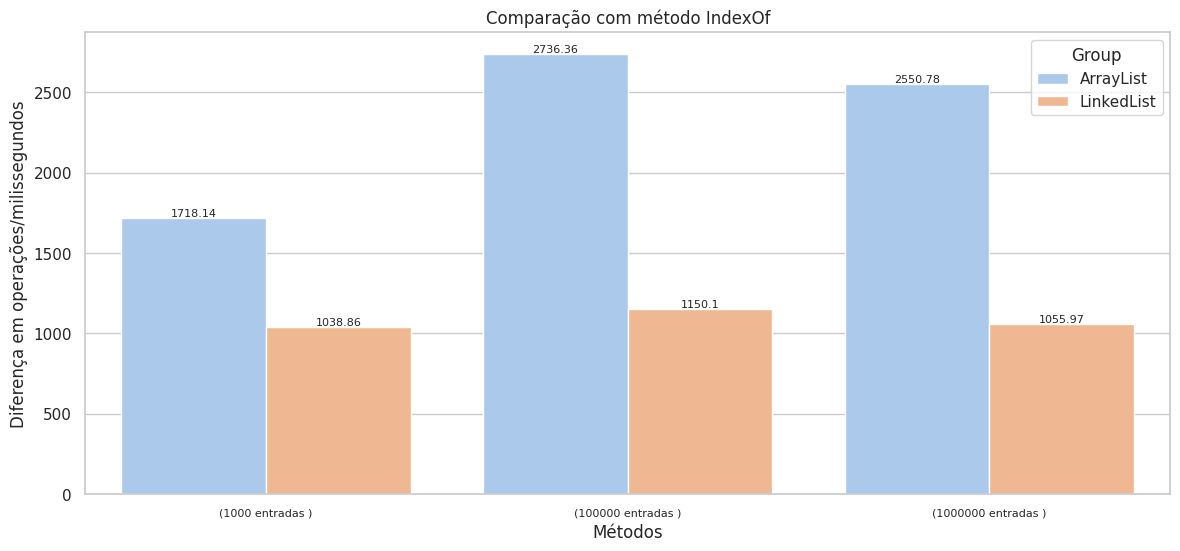

In [145]:
graph = sns.barplot(data=indexOf,x="XLabel",y=indexOf['Diff'],hue='Group', dodge=True, palette='pastel')

plt.title("Comparação com método IndexOf")

plt.xlabel("Métodos")
plt.ylabel("Diferença em operações/milissegundos")

plt.yscale("linear")

for container in graph.containers:
    graph.bar_label(container,fontsize=8)
plt.xticks(rotation=0,fontsize=8)

### IndexOf
A partir do gráfico acima, percebemos que <b>ArrayLists</b> dominam, com uma grande margem em todas as quantidades de entradas, em relação as <b>LinkedLists</b>. Dentre alguns dos motivos que levam a esses resultados, temos:

1. Lógica das estruturas
2. Complexidade do método
3. Uso do CPU e memória

#### Lógica das Estruturas:
- Sabe-se que por <b>ArrayLists</b> serem listas implementadas em <i>arrays</i>, os elementos são armazenados conjuntamente na memória, o que garante o acesso destes em tempo constante <i>O(1)</i>.
- Por outro lado, <b>LinkedLists</b> são listas abstraidas de <i>nós encadeados</i>, em que cada nó faz referências com os elementos seguintes e anteriores. Com isso, deve-se percorrer a lista sequencialmente para encontrar e acessar um elementos, custando no pior caso <i>O(n)</i>

#### Complexidade do método:
- <b>ArrayList</b>: custo constante, pois tem um array na memória que é rapidamente acessado
- <b>LinkedList</b>: custo proporcional à entrada, pois tem ponteiros que são acessados sequencialmente de forma lenta

#### Uso de CPU e Memória:
- Os <b>ArraysLists</b> aproveitam-se da <i>locality of reference</i>, o que permite que o cache acelere a busca
- As <b>LinkedLists</b> sofrem com <i>cache misses</i>, devido a dispersão dos nós na memória.



## Observações
#### Locality of Reference:
É a tendência de um processador de acessar o(s) mesmo(s) bloco(s) de memória repetidas vezes em um curto intervalo de tempo. Existem dois tipos principais, a especial e a temporal.  

<i>Fonte:William., Stallings (2010). Computer organization and architecture : designing for performance</i>